# DuckDB Medallion Architecture Demo  
## Bronze → Silver → Gold with SQL Insights

This notebook demonstrates a simplified **Medallion Architecture** pipeline using DuckDB.

Pipeline stages:

**Bronze** → Raw CSV data  

**Silver** → Cleaned and standardized data  

**Gold** → Aggregated analytics tables  

## Bronze Layer
	•	Raw CSV files
	•	Direct ingestion from:

data/bronze/insurance.*.csv

## Silver Layer
	•	Cleaned and standardized data
	•	Data cleaning
	•	Standardization
	•	Type casting
	•	Normalized categorical values

## Gold Layer
	•	Aggregated analytics tables
	•	Business-ready data


We then run **12 SQL insight queries** and visualize the results.


## 1. Setup Environment

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


## 2. Connect to DuckDB

In [2]:
con = duckdb.connect("medallion_demo.duckdb")

In [3]:
print("con=", con)

con= <_duckdb.DuckDBPyConnection object at 0x1127ab9b0>


## 3. Bronze Layer (Raw Data)

The bronze layer stores the raw source files exactly as they arrive.


In [4]:
con.execute("""
CREATE OR REPLACE TABLE bronze_insurance AS
SELECT *
FROM read_csv_auto('insurance/data/bronze/insurance.*.csv')
""")

con.execute("SELECT * FROM bronze_insurance LIMIT 5").df()

,age,gender,bmi,children,smoker,region,charges
0,22,female,23.20,1,False,northwest,5605.93
1,54,male,30.60,0,False,northeast,7118.87
2,48,male,31.31,0,True,southwest,40381.51
3,38,female,27.49,0,True,southwest,21178.05
4,38,male,33.10,0,False,northwest,12829.41


# Inspect Types in Bronze

In [5]:
con.execute("DESCRIBE bronze_insurance").df()

,column_name,column_type,null,key,default,extra
0,age,BIGINT,YES,None,None,None
1,gender,VARCHAR,YES,None,None,None
2,bmi,DOUBLE,YES,None,None,None
3,children,BIGINT,YES,None,None,None
4,smoker,BOOLEAN,YES,None,None,None
5,region,VARCHAR,YES,None,None,None
6,charges,DOUBLE,YES,None,None,None


## 4. Silver Layer (Cleaned Data)

The silver layer standardizes and validates data.


In [6]:
con.execute("""
CREATE OR REPLACE TABLE silver_insurance AS
SELECT
    CAST(age AS INTEGER) AS age,
    LOWER(TRIM(gender::VARCHAR)) AS gender,
    CAST(bmi AS DOUBLE) AS bmi,
    CAST(children AS INTEGER) AS children,
    LOWER(TRIM(smoker::VARCHAR)) AS smoker,
    LOWER(TRIM(region::VARCHAR)) AS region,
    CAST(charges AS DOUBLE) AS charges
FROM bronze_insurance;
""")

con.execute("SELECT * FROM silver_insurance LIMIT 5").df()


,age,gender,bmi,children,smoker,region,charges
0,22,female,23.20,1,false,northwest,5605.93
1,54,male,30.60,0,false,northeast,7118.87
2,48,male,31.31,0,true,southwest,40381.51
3,38,female,27.49,0,true,southwest,21178.05
4,38,male,33.10,0,false,northwest,12829.41


## 5. Gold Layer (Analytics Table)

The gold layer stores aggregated analytics-ready tables.


In [7]:
con.execute("""
CREATE OR REPLACE TABLE gold_insurance_summary AS
SELECT
    smoker,
    region,
    COUNT(*) AS total_patients,
    AVG(charges) AS avg_charges
FROM silver_insurance
GROUP BY smoker, region
""")


---
## Insight Query 1: Average Charges by Region

**Business Insight:**  
Understanding regional cost differences can help insurers identify geographic risk patterns.


In [8]:

df = con.execute("""
SELECT region, AVG(charges) avg_charges
FROM silver_insurance
GROUP BY region
ORDER BY avg_charges DESC
""").df()
df.head()


,region,avg_charges
0,northeast,17247.142607
1,northwest,16997.721412
2,southeast,16756.908670
3,southwest,16417.575123


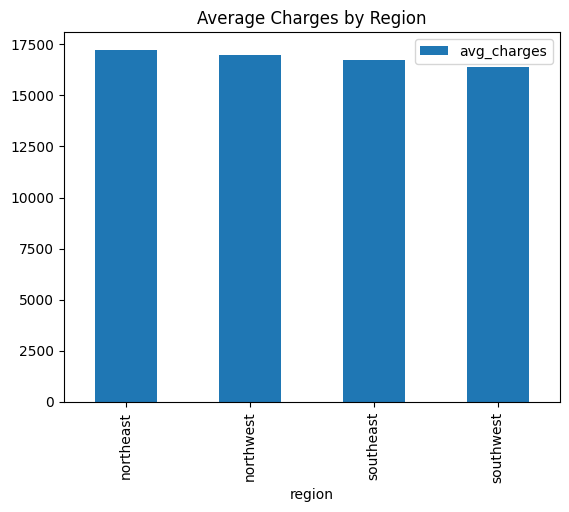

In [9]:

df.plot(kind='bar', x='region', y='avg_charges' if 'avg_charges' in df.columns else df.columns[1])
plt.title("Average Charges by Region")
plt.show()


---
## Insight Query 2: Charges by Smoking Status

**Business Insight:**  
Smoking is a major risk factor affecting healthcare costs.


In [10]:

df = con.execute("""
SELECT smoker, AVG(charges) avg_charges
FROM silver_insurance
GROUP BY smoker
""").df()
df.head()


,smoker,avg_charges
0,true,37149.764367
1,false,12191.119137


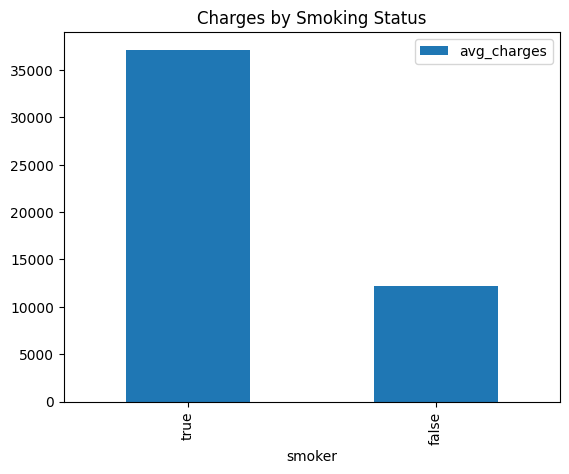

In [11]:

df.plot(kind='bar', x='smoker', y='avg_charges' if 'avg_charges' in df.columns else df.columns[1])
plt.title("Charges by Smoking Status")
plt.show()


---
## Insight Query 3: Average Charges by Gender

**Business Insight:**  
Examining potential gender-based differences in healthcare expenses.


In [12]:

df = con.execute("""
SELECT gender, AVG(charges) avg_charges
FROM silver_insurance
GROUP BY gender
""").df()
df.head()


,gender,avg_charges
0,female,16901.305762
1,male,16805.490642


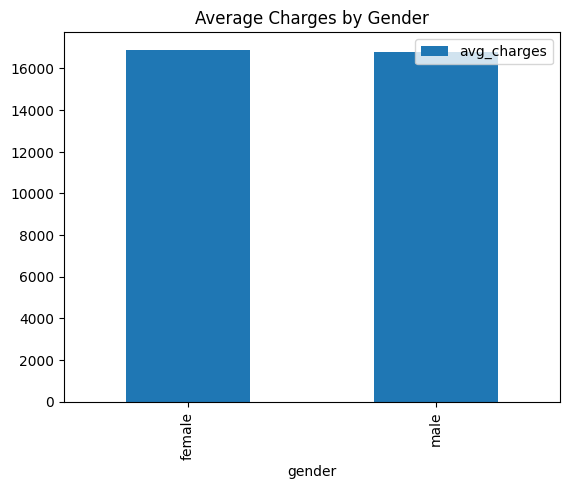

In [13]:

df.plot(kind='bar', x='gender', y='avg_charges' if 'avg_charges' in df.columns else df.columns[1])
plt.title("Average Charges by Gender")
plt.show()


---
## Insight Query 4: Charges by Number of Children

**Business Insight:**  
Family size may influence healthcare spending patterns.


In [14]:

df = con.execute("""
SELECT children, AVG(charges) avg_charges
FROM silver_insurance
GROUP BY children
ORDER BY children
""").df()
df.head()


,children,avg_charges
0,0,16381.876405
1,1,16437.449589
2,2,17157.924790
3,3,18387.096235
4,4,19357.598689


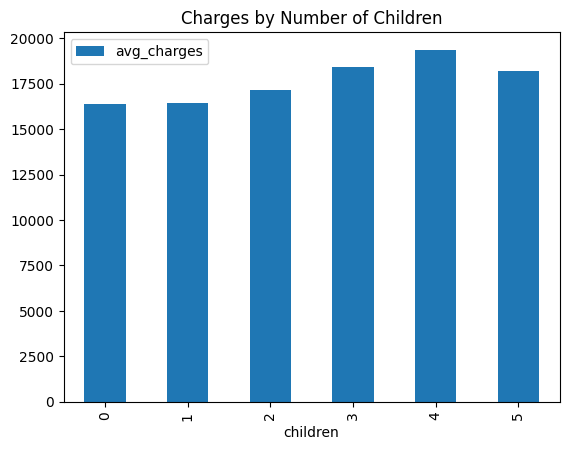

In [15]:

df.plot(kind='bar', x='children', y='avg_charges' if 'avg_charges' in df.columns else df.columns[1])
plt.title("Charges by Number of Children")
plt.show()


---
## Insight Query 5: BMI vs Charges Trend

**Business Insight:**  
Understanding how BMI correlates with insurance costs.


In [16]:

df = con.execute("""
SELECT bmi, charges
FROM silver_insurance
LIMIT 1000
""").df()
df.head()


,bmi,charges
0,23.20,5605.93
1,30.60,7118.87
2,31.31,40381.51
3,27.49,21178.05
4,33.10,12829.41


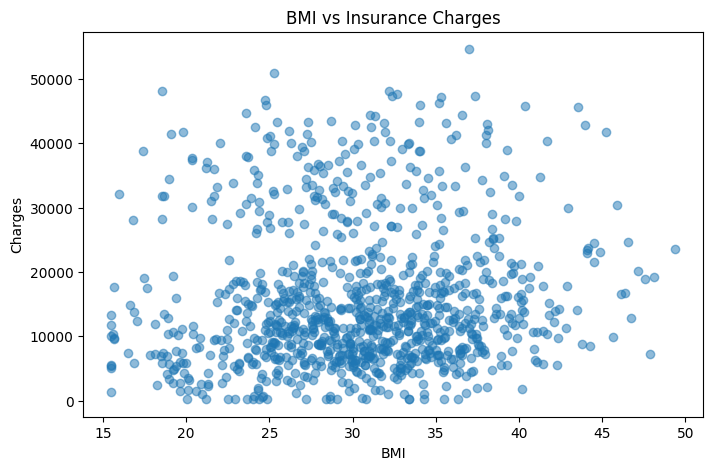

In [17]:

plt.figure(figsize=(8,5))

plt.scatter(df["bmi"], df["charges"], alpha=0.5)

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()


---
## Insight Query 6: Age vs Charges Trend

**Business Insight:**  
Healthcare costs often increase with age.


In [18]:

df = con.execute("""
SELECT age, charges
FROM silver_insurance
LIMIT 1000
""").df()
df.head()


,age,charges
0,22,5605.93
1,54,7118.87
2,48,40381.51
3,38,21178.05
4,38,12829.41


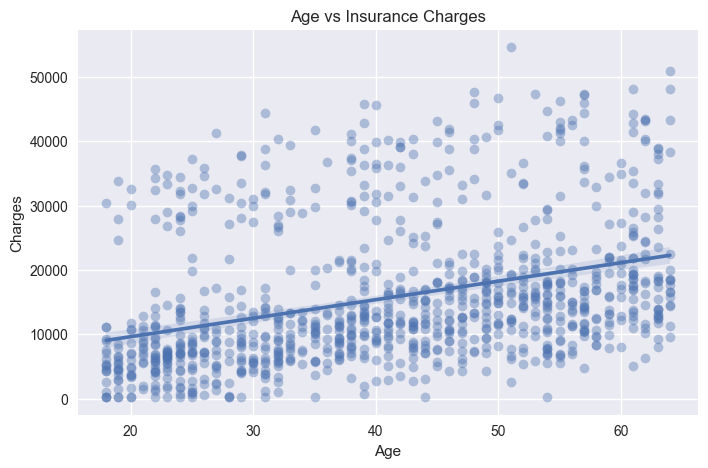

In [19]:

import seaborn as sns
plt.style.use("seaborn-v0_8")

plt.figure(figsize=(8,5))

sns.regplot(
    x="age",
    y="charges",
    data=df,
    scatter_kws={"alpha":0.4}
)

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

---
## Insight Query 7: Average Charges by Region and Smoking

**Business Insight:**  
Combining lifestyle and geographic factors for deeper insights.


In [20]:

df = con.execute("""
SELECT region, smoker, AVG(charges) avg_charges
FROM silver_insurance
GROUP BY region, smoker
""").df()
df.head()


,region,smoker,avg_charges
0,northeast,false,12597.395427
1,southeast,false,12055.909272
2,northwest,true,37549.621937
3,southwest,true,36716.531090
4,northeast,true,37581.751244


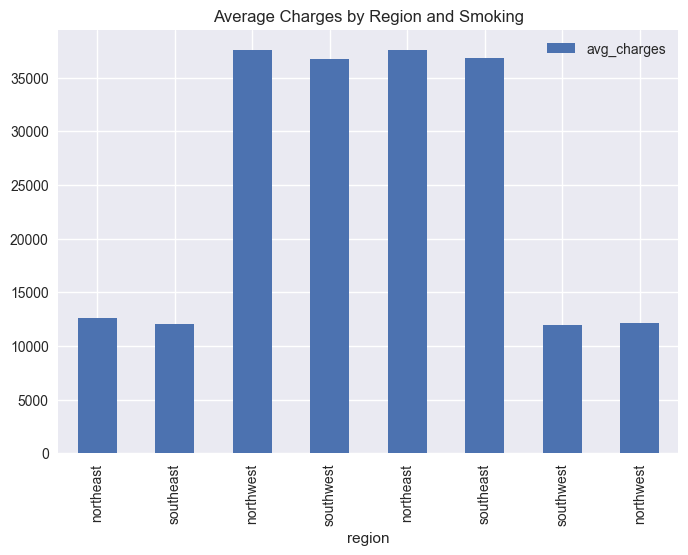

In [21]:

df.plot(kind='bar', x='region', y='avg_charges' if 'avg_charges' in df.columns else df.columns[1])
plt.title("Average Charges by Region and Smoking")
plt.show()


---
## Insight Query 8: Top Regions by Average Charges

**Business Insight:**  
Identifying the most expensive regions for insurance coverage.


In [22]:

df = con.execute("""
SELECT region, AVG(charges) avg_charges
FROM silver_insurance
GROUP BY region
ORDER BY avg_charges DESC
LIMIT 4
""").df()
df.head()


,region,avg_charges
0,northeast,17247.142607
1,northwest,16997.721412
2,southeast,16756.908670
3,southwest,16417.575123


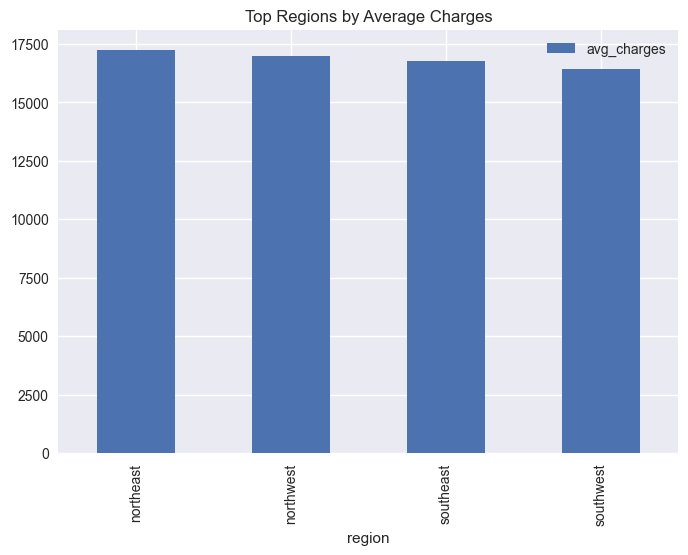

In [23]:

df.plot(kind='bar', x='region', y='avg_charges' if 'avg_charges' in df.columns else df.columns[1])
plt.title("Top Regions by Average Charges")
plt.show()


---
## Insight Query 9: Average BMI by Region

**Business Insight:**  
Examining regional health patterns.


In [24]:

df = con.execute("""
SELECT region, AVG(bmi) avg_bmi
FROM silver_insurance
GROUP BY region
""").df()
df.head()


,region,avg_bmi
0,southwest,29.967103
1,southeast,30.145367
2,northwest,30.132863
3,northeast,30.309022


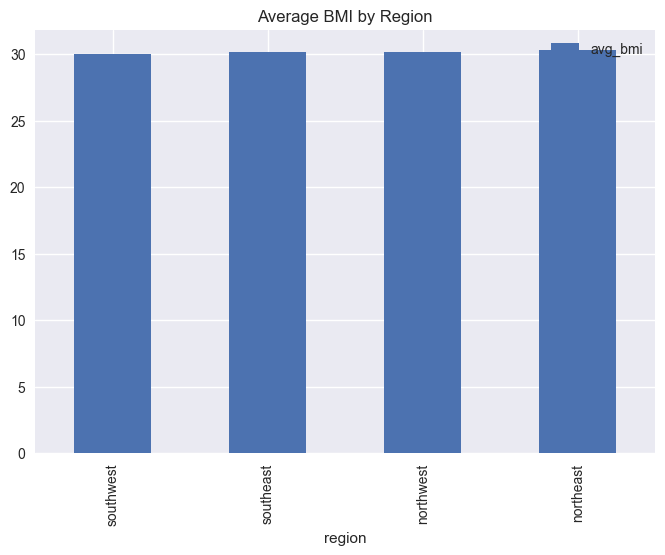

In [25]:

df.plot(kind='bar', x='region', y='avg_bmi' if 'avg_bmi' in df.columns else df.columns[1])
plt.title("Average BMI by Region")
plt.show()


---
## Insight Query 10: Average Charges by Age Group

**Business Insight:**  
Grouping patients into age segments for insurance pricing strategies.


In [26]:

df = con.execute("""
SELECT
CASE
WHEN age < 30 THEN 'Under 30'
WHEN age < 50 THEN '30-49'
ELSE '50+'
END AS age_group,
AVG(charges) avg_charges
FROM silver_insurance
GROUP BY age_group
""").df()
df.head()


,age_group,avg_charges
0,30-49,16490.527505
1,Under 30,11646.222652
2,50+,21431.590273


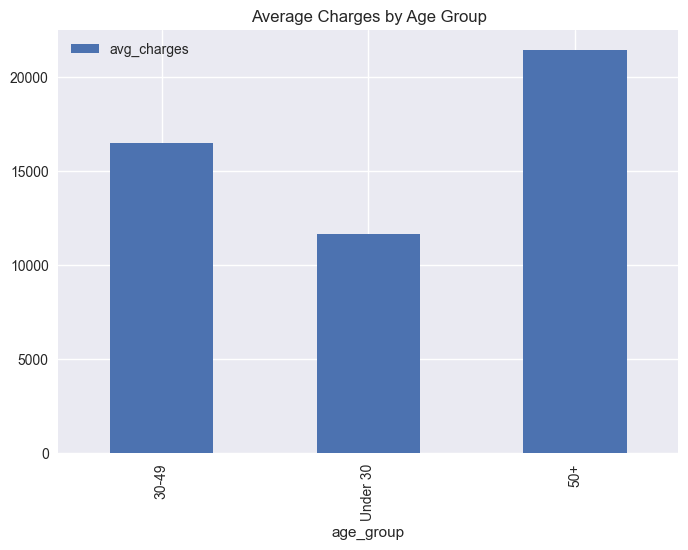

In [27]:

df.plot(kind='bar', x='age_group', y='avg_charges' if 'avg_charges' in df.columns else df.columns[1])
plt.title("Average Charges by Age Group")
plt.show()


---
## Insight Query 11: Smoker Distribution

**Business Insight:**  
Understanding the proportion of smokers among insured individuals.


In [28]:

df = con.execute("""
SELECT smoker, COUNT(*) total
FROM silver_insurance
GROUP BY smoker
""").df()
df.head()


,smoker,total
0,true,971
1,false,4229


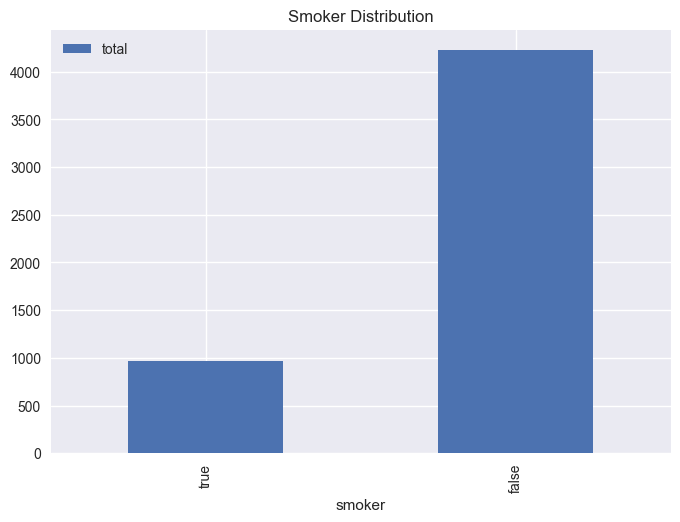

In [29]:

df.plot(kind='bar', x='smoker', y='total' if 'total' in df.columns else df.columns[1])
plt.title("Smoker Distribution")
plt.show()


---
## Insight Query 12: Regional Patient Counts

**Business Insight:**  
Analyzing population distribution across regions.


In [30]:

df = con.execute("""
SELECT region, COUNT(*) total
FROM silver_insurance
GROUP BY region
""").df()
df.head()


,region,total
0,southwest,1177
1,southeast,1526
2,northwest,1331
3,northeast,1166


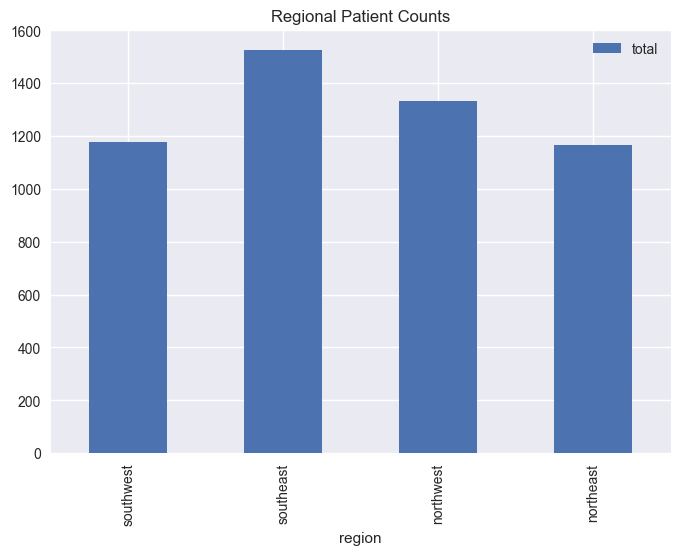

In [31]:

df.plot(kind='bar', x='region', y='total' if 'total' in df.columns else df.columns[1])
plt.title("Regional Patient Counts")
plt.show()


# Visualization 1 — Smoking Impact on Insurance Charges

## Business Insight

## Smoking dramatically increases healthcare costs.

## Smoking is the strongest predictor of high medical costs

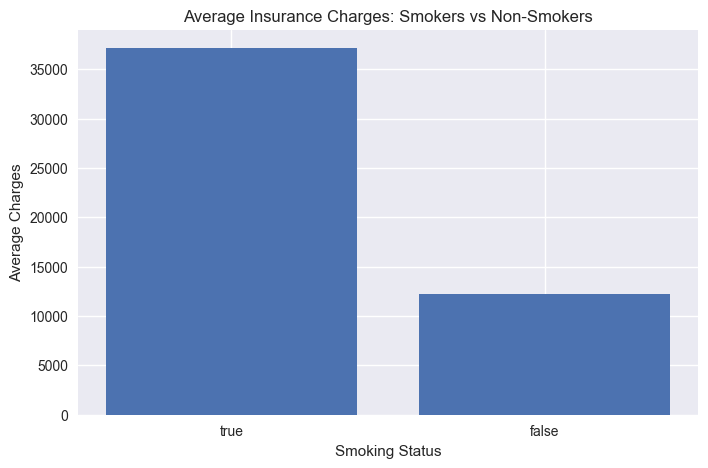

In [32]:
# Smoking vs Charges

plt.style.use("seaborn-v0_8")

smoker_analysis = con.execute("""
SELECT
    smoker,
    AVG(charges) AS avg_charges
FROM silver_insurance
GROUP BY smoker
""").df()

plt.figure(figsize=(8,5))

plt.bar(smoker_analysis["smoker"], smoker_analysis["avg_charges"])

plt.title("Average Insurance Charges: Smokers vs Non-Smokers")
plt.xlabel("Smoking Status")
plt.ylabel("Average Charges")

plt.show()

# Visualization 2 — Age vs Charges Trend

## Business Insight

## Healthcare costs tend to increase with age.

## Age is positively correlated with healthcare costs

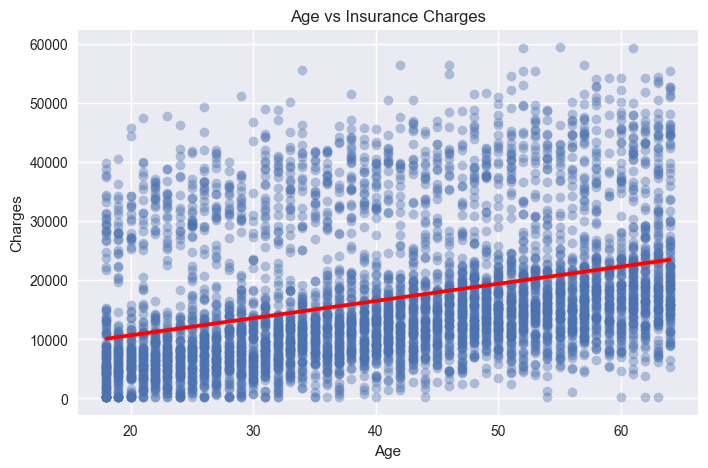

In [34]:
# Age vs Charges Trend (Clean Version)

import seaborn as sns

df_age = con.execute("""
SELECT age, charges
FROM silver_insurance
WHERE age IS NOT NULL
AND charges IS NOT NULL
""").df()

# Remove extreme outliers (optional but useful for teaching)
df_age = df_age[df_age["charges"] < 60000]

plt.figure(figsize=(8,5))

sns.regplot(
    x="age",
    y="charges",
    data=df_age,
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

# Visualization 3 — BMI Risk Groups

## Business Insight

## Higher BMI is associated with increased insurance costs.

## We see the health risk relationship between BMI and insurance costs.

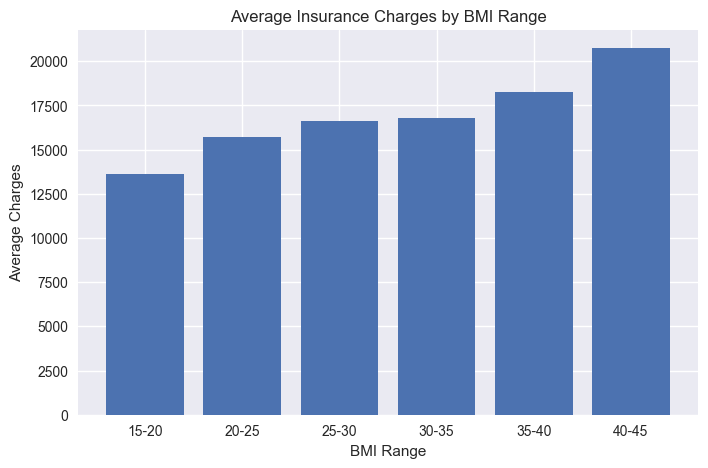

In [36]:
# BMI Risk Analysis (Clean Version)

df_bmi = con.execute("""
SELECT bmi, charges
FROM silver_insurance
WHERE bmi IS NOT NULL
AND charges IS NOT NULL
""").df()

df_bmi["bmi_group"] = pd.cut(
    df_bmi["bmi"],
    bins=[15,20,25,30,35,40,45],
    labels=["15-20","20-25","25-30","30-35","35-40","40-45"]
)

bmi_analysis = df_bmi.groupby("bmi_group", observed=True)["charges"].mean().reset_index()

plt.figure(figsize=(8,5))

plt.bar(bmi_analysis["bmi_group"], bmi_analysis["charges"])

plt.title("Average Insurance Charges by BMI Range")
plt.xlabel("BMI Range")
plt.ylabel("Average Charges")

plt.show()